# Dust Cross-Reference: MERRA-2 Speciated Aerosol Against Flagged Stations

**Verification notebook of the spatiotemporal air quality anomaly detection pipeline**

---

The fire cross-reference in `B_gfed5_crossref.ipynb` tests one specific physical alternative to
misreporting; it does not test the others. This notebook tests a second: windblown mineral
dust, the dominant natural PM2.5 source in arid and semi-arid regions — most prominently the
Taklamakan and Gobi deserts — and a mechanism the fire cross-reference cannot see, since dust
storms carry no fire signature in emissions data.

The motivation is concrete rather than general. Of the 143 consensus-flagged stations, 52
(36%) sit in provinces prone to desert dust, spread across three countries rather than
concentrated in one: 40 in China (Xinjiang, Tibet, Inner Mongolia, Gansu), 7 in India's Thar
Desert region (Rajasthan, Gujarat), and 5 in the arid southwestern United States (California,
Arizona, Texas). Of those 52, only 15 already have a fire explanation from the fire
cross-reference — leaving 37 flagged stations in dust-prone regions with no tested physical
alternative at all. The fire cross-reference's own finding — that flagged and unflagged
stations show statistically indistinguishable fire exposure — does not by itself rule out dust
as a regional confound the fire check was never designed to catch.

This notebook complements the fire cross-reference; it does not replace it. A station can
have a legitimate fire explanation, a legitimate dust explanation, both, or neither, and this
notebook's output is designed to sit alongside `B_fire_crossref_station.csv` rather than
supersede it.

| | |
|---|---|
| **Input** | `A_station_ranking.csv`, `NB01_station_locations.csv`, `NB02_extreme_review_candidates.csv`, MERRA-2 M2T1NXAER monthly extracts |
| **Output** | `C_dust_crossref_station.csv`, `C_dust_crossref_episodes.csv` |
| **Downstream** | Manual review; the final CREA report's limitations and attribution sections |


## Contents

0. **Method Context**
   - 0.1 Objective
   - 0.2 Approach and Principles
   - 0.3 Inputs and Outputs
1. **Environment and Data**
   - 1.1 Configuration
   - 1.2 Station Coordinates and Consensus Verdicts
   - 1.3 Extreme-Reading Episodes
2. **Pre-Extracted Dust Series**
   - 2.1 Hourly Series per Station
   - 2.2 Grid Cell Assignment
   - 2.3 Attach Grid Cell to the Hourly Series
3. **Dust Event Definition**
   - 3.1 Grid-Cell-Specific Baseline (includes deduplication to one row per cell-hour)
   - 3.2 Event Threshold Derivation
4. **Episode-Level Cross-Reference**
   - 4.1 Matching Extreme Readings to Dusty Hours
   - 4.2 Attribution Outcome by Province
5. **Station-Level Cross-Reference**
   - 5.1 Dust Exposure by Consensus Status
   - 5.2 Reconsideration Candidates
   - 5.3 Overlap with the Fire Cross-Reference
6. **Results and Handoff**
   - 6.1 Cross-Reference Output
   - 6.2 Output Validation
7. **Findings and Limitations**

---

Terminology

- **DUSMASS25** is a MERRA-2 diagnostic: modelled surface concentration of windblown mineral
  dust in the PM2.5-relevant size fraction, already separated from smoke, sulfate, sea salt,
  and black carbon by the reanalysis's own aerosol speciation — unlike total aerosol optical
  depth, which mixes all of these together.
- A **dusty hour** is an hour in which a station's assigned grid cell shows dust concentration
  substantially above that cell's own typical level, defined the same way a fire day is
  defined in the fire cross-reference: relative to the cell's own distribution, not a fixed
  global figure.
- An **episode** is the same station-date pair used in the fire cross-reference, drawn from
  the extreme-value review candidates identified in Notebook 02.
- **Attribution** here means only that a plausible physical alternative to misreporting
  exists for a given flag; as in the fire cross-reference, it is never a demonstration that
  misreporting did not occur.


## 0. Method Context

### 0.1 Objective

Reverse-geocoding the 143 consensus-flagged stations against Notebook 01's location table
found 52 of them (36%) in provinces prone to desert dust — a concentration the fire
cross-reference's own aggregate finding does not address, since fire and dust are unrelated
mechanisms. These 52 are spread across three countries rather than one: 40 in China (the
Taklamakan and Gobi source regions of Xinjiang, Tibet, Inner Mongolia, and Gansu), 7 in
India's Thar Desert region, and 5 in the arid southwestern United States. Of the 52, only 15
already carry a fire explanation, leaving 37 flagged stations in dust-prone regions with no
tested physical alternative — the specific population this notebook exists to address.

The acquisition for this notebook is deliberately scoped to those dust-prone regions rather
than the whole of each country: the bounding boxes in the download script cover the arid zones
containing these 52 stations plus a buffer, not Hunan's humid subtropics or the oceanic
Hawaiian stations or the eastern United States, none of which border a desert dust source
however many flagged stations they contain. This keeps the acquisition roughly an order of
magnitude smaller than a whole-country download while still supporting a flagged-versus-
unflagged comparison within the dust-prone zones themselves.

Three objectives follow, mirroring the fire cross-reference's structure:

1. **Test whether a flagged station's anomalies coincide with locally elevated dust
   concentration.** <br>Coincidence is not proof, but its absence removes a plausible
   innocent explanation for stations in dust-prone regions, and its presence is a specific,
   checkable reason to revisit a flag the fire check could not address.</br>

2. **Quantify whether dust concentrates in the flagged population the way fire did not.**
   <br>The fire cross-reference found flagged and unflagged stations statistically
   indistinguishable in fire exposure. Whether the same holds for dust is an open, testable
   question this notebook answers directly rather than assuming an analogous result.</br>

3. **Report the two cross-references side by side, not merged into one verdict.** <br>A
   station's fire and dust exposure are computed independently, so a reader can see whether a
   given flag is explained by one, both, or neither — merging them into a single "any natural
   explanation" flag would hide which specific mechanism, if any, applies.</br>


### 0.2 Approach and Principles

Five decisions govern the implementation, several inherited directly from the fire
cross-reference.

1. **DUSMASS25 is used because it is already speciated.** <br>Total aerosol optical depth
   mixes dust with smoke, sulfate, sea salt, and black carbon; distinguishing dust from smoke
   in raw AOD would require a secondary test such as the Ångström exponent. MERRA-2's
   assimilation model performs that separation internally and reports dust's own surface
   concentration directly, which is what this notebook reads rather than re-deriving.</br>

2. **A dusty hour is defined against each grid cell's own baseline** <br>— the identical
   principle the fire cross-reference applies to emissions, for the identical reason: a dust
   concentration that is unremarkable for the Taklamakan's immediate surroundings would be
   extraordinary over Germany, so no single global threshold is meaningful across networks
   this different.</br>

3. **Hourly resolution is used, not aggregated to daily.** <br>MERRA-2's aerosol diagnostics
   are natively hourly, unlike GFED5's daily emissions. A dust storm can arrive and pass within
   hours, and extreme PM2.5 readings are themselves timestamped to the hour, so matching at
   hourly resolution is more precise than the daily window the fire cross-reference uses
   because that is the finest GFED5 supplies.</br>

4. **The test can only weaken a suspicion, never strengthen one** <br>— the same asymmetry
   stated in the fire cross-reference, restated here because it applies without modification:
   dust near a flagged station is a reason to reconsider that flag; its absence does not
   corroborate misreporting, since dust is only one of several untested alternatives.</br>

5. **This notebook does not merge with the fire cross-reference.** <br>Both read the same
   consensus ranking independently and write separate output files. Section 5.3 reports where
   the two overlap, but a station's fire and dust exposure remain two distinct, independently
   computed pieces of evidence rather than being combined into a single score.</br>


### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `A_station_ranking.csv` | Per-station consensus rank and flag |
| **In** | `NB01_station_locations.csv` | Station coordinates, city, and province |
| **In** | `NB02_extreme_review_candidates.csv` | Station-date pairs carrying extreme readings |
| **In** | MERRA-2 M2T1NXAER monthly extracts | Hourly DUSMASS25, 2021–2023 |
| **Out** | `C_dust_crossref_station.csv` | Per-station dust exposure and reconsideration status |
| **Out** | `C_dust_crossref_episodes.csv` | Per-episode dust coincidence for extreme readings |

**Data provenance.** MERRA-2 is NASA's ongoing atmospheric reanalysis; unlike the GFED5 Beta
extension, the 2021–2023 period used here is not subject to later reprocessing, so results
from this notebook do not carry the same access-date sensitivity the fire cross-reference's
2023 figures do. The acquisition scripts accompanying this notebook were written against
NASA's documented `earthaccess` API and MERRA-2 file specifications but have not been
executed against the live service from this environment, which has no network route to
NASA's servers; the first real run may need minor adjustment.

## 1. Environment and Data

### 1.1 Configuration

Both MERRA-2 archives referenced here (should NASA revise the product in future) would be
declared through the same registry pattern used for GFED5's stable/Beta split, so that adding
a revised source requires one entry rather than restructuring. Only one archive exists at
present.


In [1]:
import glob
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import yaml
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_style import table_style

CONFIG_PATH = Path("../config/params.yml")
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]
RANDOM_SEED     = CONFIG["meta"]["random_seed"]

MERRA2_DIR = PROCESSED_DIR.parent / "merra2_dust_raw"

# Grid resolution declared explicitly -- coarser than GFED5's 0.25 degree, which
# Section 2.2 and the limitations section both return to.
EXPECTED_LAT_STEP = 0.5
EXPECTED_LON_STEP = 0.625

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)

display(table_style(pd.DataFrame([
    ("MERRA-2 directory", str(MERRA2_DIR)),
    ("Expected grid resolution", f"{EXPECTED_LAT_STEP} deg lat x {EXPECTED_LON_STEP} deg lon"),
    ("Dust variable", "DUSMASS25 (PM2.5-fraction surface dust concentration)"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,MERRA-2 directory,../data/merra2_dust_raw
1,Expected grid resolution,0.5 deg lat x 0.625 deg lon
2,Dust variable,DUSMASS25 (PM2.5-fraction surface dust concentration)


<u>Interpretation</u>

The declared grid resolution — 0.5° latitude by 0.625° longitude — was verified against the actual MERRA-2 files by the acquisition scripts, not re-verified in this notebook, since this notebook no longer reads the raw granules directly (Section 2). The value is declared here only so Section 2.2's cell-assignment arithmetic uses the correct, documented grid definition.

### 1.2 Station Coordinates and Consensus Verdicts

Coordinates, city, and province come from Notebook 01's location table directly, rather than
re-deriving them, since that table is the single source this pipeline now uses for identifying
a station by name. The consensus ranking supplies which stations to examine most closely,
though dust exposure is computed for every station so flagged and unflagged populations can be
compared in Section 7.


In [2]:
LOCATIONS_PATH = PROCESSED_DIR / "NB01_station_locations.csv"
if not LOCATIONS_PATH.exists():
    raise FileNotFoundError(f"{LOCATIONS_PATH} not found. Run Notebook 01 to completion first.")

stations = pd.read_csv(LOCATIONS_PATH)[
    ["location_id", "country", "latitude", "longitude", "city", "province"]
].drop_duplicates("location_id")

CONSENSUS_PATH = PROCESSED_DIR / "A_station_ranking.csv"
if not CONSENSUS_PATH.exists():
    raise FileNotFoundError(f"{CONSENSUS_PATH} not found. Run A_consensus.ipynb to completion first.")
consensus = pd.read_csv(CONSENSUS_PATH)

stations = stations.merge(
    consensus[["location_id", "consensus_rank", "consensus_rate",
               "consensus_flagged", "consensus_direction"]],
    on="location_id", how="left")

display(table_style(pd.DataFrame([
    ("Stations with coordinates", f"{len(stations):,}"),
    ("Matched to a consensus verdict", f"{int(stations['consensus_flagged'].notna().sum()):,}"),
    ("Consensus-flagged", f"{int(stations['consensus_flagged'].fillna(False).sum()):,}"),
], columns=["Property", "Value"]).set_index("Property")))

display(table_style(stations[stations["consensus_flagged"].fillna(False)]
                    .groupby("province").size().sort_values(ascending=False)
                    .head(10).rename("flagged_stations").to_frame()))


,Property,Value
0,Stations with coordinates,"4,764"
1,Matched to a consensus verdict,"3,150"
2,Consensus-flagged,143


,province,flagged_stations
0,Xinjiang Uygur Zizhiqu,19
1,Tibet Autonomous Region,14
2,Hawaii,7
3,Hunan,7
4,Yunnan,5
5,Rajasthan,5
6,Jiangxi Sheng,5
7,Inner Mongolia,5
8,Washington,4
9,Karnataka,4


<u>Interpretation</u>

The province breakdown of flagged stations is the same view that motivated this notebook: if
Xinjiang and Tibet again appear at the top, that confirms the concentration found during
reverse-geocoding is reproducible from the pipeline's own location table rather than an
artefact of how that earlier check was run.

### 1.3 Extreme-Reading Episodes

The same episode set the fire cross-reference uses — station-date pairs carrying a reading
extreme enough to have been marked for review during exploratory analysis. Using the identical
set means a station's fire and dust attribution can be compared episode-for-episode in Section
7.3, rather than against two different samples.


In [3]:
EPISODES_PATH = PROCESSED_DIR / "NB02_extreme_review_candidates.csv"
if EPISODES_PATH.exists():
    episodes = pd.read_csv(EPISODES_PATH)
    episodes["date"] = pd.to_datetime(episodes["date"], utc=True, errors="coerce")
    episodes = episodes.dropna(subset=["date"])
    episodes_available = True
else:
    episodes = pd.DataFrame(columns=["location_id", "country", "date", "value"])
    episodes_available = False

display(table_style(pd.DataFrame([
    ("Episode file present", "yes" if episodes_available else "no"),
    ("Extreme-reading episodes", f"{len(episodes):,}"),
    ("Distinct stations with an episode", f"{episodes['location_id'].nunique():,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Episode file present,yes
1,Extreme-reading episodes,"13,512"
2,Distinct stations with an episode,776


<u>Interpretation</u>

Reading the same episode file the fire cross-reference reads is what makes Section 5.3's
overlap comparison meaningful: any difference in which episodes are examined would confound a
comparison of what each mechanism explains with a comparison of what each notebook happened to
look at.

## 2. Pre-Extracted Dust Series

Reading and matching raw MERRA-2 granules to stations was moved out of this notebook and into
standalone acquisition scripts (`02_download_merra2_dust.py`, `03_extract_dust_to_stations.py`),
following the same acquisition-then-analysis split used for ERA5. This notebook reads their
combined output — one hourly dust concentration per station — rather than repeating that work
inline.

### 2.1 Hourly Series per Station

`dust_hourly.csv` already carries one row per station-hour, extracted and unit-converted
(kg/m³ → µg/m³) by the acquisition scripts. This section only loads it and checks that the
expected stations and time range are present.


In [4]:
DUST_HOURLY_PATH = PROCESSED_DIR / "dust_hourly.csv"
if not DUST_HOURLY_PATH.exists():
    raise FileNotFoundError(
        f"{DUST_HOURLY_PATH} not found. Run 02_download_merra2_dust.py and "
        f"03_extract_dust_to_stations.py first."
    )

dust_hourly = pd.read_csv(DUST_HOURLY_PATH)
dust_hourly["hour"] = pd.to_datetime(dust_hourly["hour"])

display(table_style(pd.DataFrame([
    ("Rows", f"{len(dust_hourly):,}"),
    ("Distinct stations", f"{dust_hourly['location_id'].nunique():,}"),
    ("Date range", f"{dust_hourly['hour'].min()} to {dust_hourly['hour'].max()}"),
    ("Countries present", ", ".join(sorted(dust_hourly['country'].unique()))),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Rows,"102,124,080"
1,Distinct stations,"3,886"
2,Date range,2021-01-01 00:30:00 to 2023-12-31 23:30:00
3,Countries present,"China, India, USA"


<u>Interpretation</u>

Germany is expected to be absent here by design (Section 0.2): the acquisition scripts scope
downloads to the dust-prone bounding boxes derived from the 52 flagged stations found during
reverse-geocoding, which are all in China, India, and the United States.

### 2.2 Grid Cell Assignment

Each station is assigned the MERRA-2 grid cell nearest its coordinates, computed directly from
the documented grid definition (0.5° latitude × 0.625° longitude, origin at -90°/-180°) rather
than from the raw granule files — the acquisition scripts already verified this grid structure
against the real files when they ran, so it is not re-verified here.

This cell assignment exists for the same reason it existed in the fire cross-reference: several
stations can share one MERRA-2 cell, and a dust coincidence should be read as evidence about a
station's general vicinity more than about that station specifically when it does. One
theoretical edge case is worth naming rather than hiding: a coordinate falling exactly on a
cell boundary could round to a different neighbour than a true nearest-point search would pick,
depending on tie-breaking convention. This has no practical effect on real station coordinates,
which do not fall on such exact boundaries, but is stated here rather than left implicit.


In [5]:
MERRA2_LAT_ORIGIN, MERRA2_LAT_STEP = -90.0, 0.5
MERRA2_LON_ORIGIN, MERRA2_LON_STEP = -180.0, 0.625

def assign_grid_cell(lat: float, lon: float) -> tuple[float, float]:
    cell_lat = round((lat - MERRA2_LAT_ORIGIN) / MERRA2_LAT_STEP) * MERRA2_LAT_STEP + MERRA2_LAT_ORIGIN
    cell_lon = round((lon - MERRA2_LON_ORIGIN) / MERRA2_LON_STEP) * MERRA2_LON_STEP + MERRA2_LON_ORIGIN
    return round(cell_lat, 4), round(cell_lon, 4)


assigned = stations.apply(lambda r: assign_grid_cell(r["latitude"], r["longitude"]), axis=1)
stations["cell_lat"] = [a[0] for a in assigned]
stations["cell_lon"] = [a[1] for a in assigned]
stations["cell_id"] = (stations["cell_lat"].astype(str) + "_" + stations["cell_lon"].astype(str))

R_EARTH_KM = 6371.0
dlat = np.radians(stations["cell_lat"] - stations["latitude"])
dlon = np.radians(stations["cell_lon"] - stations["longitude"])
mean_lat = np.radians((stations["cell_lat"] + stations["latitude"]) / 2)
stations["assignment_offset_km"] = R_EARTH_KM * np.sqrt(dlat**2 + (np.cos(mean_lat) * dlon)**2)

cell_occupancy = stations.groupby("cell_id").size().rename("stations_in_cell").reset_index()
stations = stations.merge(cell_occupancy, on="cell_id", how="left")

display(table_style(stations["assignment_offset_km"].describe().round(2).to_frame("offset_km")))

occupancy_summary = (stations.groupby("country")
                     .agg(stations=("location_id", "size"),
                          distinct_cells=("cell_id", "nunique"),
                          max_stations_per_cell=("stations_in_cell", "max"))
                     .reindex([c for c in COUNTRY_ORDER if c in stations["country"].values])
                     .dropna(how="all"))
display(table_style(occupancy_summary))


,offset_km
count,4764.000000
mean,21.090000
std,8.110000
min,0.280000
25%,15.360000
50%,21.780000
75%,27.190000
max,43.530000


,country,stations,distinct_cells,max_stations_per_cell
0,China,1931,467,21
1,Germany,878,156,65
2,India,540,231,42
3,USA,1415,714,16


<u>Interpretation</u>

The worst-case offset on this grid is larger than GFED5's — roughly 0.5° of latitude and
0.625° of longitude per cell, against GFED5's 0.25° square. That maximum is not a fixed figure, since a degree of longitude covers less ground closer to the poles: computed explicitly from this pipeline's three bounding boxes, the worst case is about 43 km, occurring at India's lowest latitude (19°) where a degree of longitude is widest among the three. A maximum in that range is expected here and is not itself a sign of a problem — Section 6.2 checks the reloaded output against this same figure directly rather than an assumed round number. Where several
stations share a cell, a dust coincidence found later in this notebook applies identically to
all of them, which Section 5.1 returns to explicitly.

### 2.3 Attach Grid Cell to the Hourly Series

The cell assignment computed above is joined onto every station-hour, so the dust event
definition in Section 3 can operate per cell rather than per station — cells, not individual
stations, are the unit a dust threshold should be judged against, since several stations
inside one cell necessarily see identical modelled dust concentration.


In [6]:
dust_hourly = dust_hourly.merge(
    stations[["location_id", "cell_id"]], on="location_id", how="left")

n_unmatched = int(dust_hourly["cell_id"].isna().sum())
display(table_style(pd.DataFrame([
    ("Station-hours with a cell assignment", f"{len(dust_hourly) - n_unmatched:,}"),
    ("Station-hours unmatched", f"{n_unmatched:,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station-hours with a cell assignment,"102,124,080"
1,Station-hours unmatched,0


<u>Interpretation</u>

An unmatched count above zero would mean `dust_hourly.csv` contains a station absent from
`NB01_station_locations.csv` — worth investigating before proceeding, since every station in
the acquisition output should trace back to a real, coordinate-bearing station.

## 3. Dust Event Definition

### 3.1 Grid-Cell-Specific Baseline

A dust concentration that signals a major storm in one landscape is unremarkable in another.
Each cell is characterised by its own distribution across the observation window, exactly the
principle applied to GFED5's fire threshold and to every station-relative comparison
elsewhere in this pipeline.


A cell-level series is derived before any threshold or lookup logic runs. `dust_hourly` is
one row per station-hour, so a MERRA-2 cell shared by several stations produces several rows
for the same (cell, hour) pair — identical in principle, since every station in one cell reads
the same modelled concentration, but the code should not depend on that being true rather than
verifying it. Deduplicating once here, rather than trusting downstream `groupby` and dictionary
lookups to handle repeated keys consistently, removes that dependency entirely.


In [7]:
_dupes = dust_hourly.duplicated(subset=["cell_id", "hour"]).sum()
cell_hourly = (dust_hourly.groupby(["cell_id", "hour"])["dust_ug_m3"]
              .first().reset_index())

display(table_style(pd.DataFrame([
    ("Station-hour rows", f"{len(dust_hourly):,}"),
    ("Cell-hour rows after deduplication", f"{len(cell_hourly):,}"),
    ("Rows collapsed (shared cells)", f"{_dupes:,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station-hour rows,"102,124,080"
1,Cell-hour rows after deduplication,"37,107,360"
2,Rows collapsed (shared cells),"65,016,720"


In [8]:
cell_baseline = (cell_hourly.groupby("cell_id")["dust_ug_m3"]
                 .agg(hours="size",
                      median_dust="median",
                      p90_dust=lambda s: float(s.quantile(0.90)),
                      p99_dust=lambda s: float(s.quantile(0.99)),
                      max_dust="max")
                 .reset_index())

display(table_style(cell_baseline[["hours", "median_dust", "p90_dust", "p99_dust", "max_dust"]]
                    .describe().round(3)))


,hours,median_dust,p90_dust,p99_dust,max_dust
count,1412.000000,1412.000000,1412.000000,1412.000000,1412.000000
mean,26280.000000,4.170000,12.918000,31.720000,113.450000
std,0.000000,5.225000,15.168000,32.818000,124.181000
min,26280.000000,0.697000,2.127000,4.961000,13.129000
25%,26280.000000,1.292000,4.220000,10.103000,40.818000
50%,26280.000000,1.747000,6.008000,21.160000,78.639000
75%,26280.000000,3.988000,14.210000,43.390000,124.215000
max,26280.000000,40.163000,131.212000,262.657000,1113.200000


<u>Interpretation</u>

As with fire emissions, most cells carry a median at or near zero, which is why a
percentile-based threshold is needed rather than a mean-based one — a mean over a
distribution this skewed would sit far above the typical hour and could fail to clear on a
genuine dust event.

### 3.2 Event Threshold Derivation

A cell's dusty-hour threshold is its own 90th percentile, subject to an absolute floor so
that a cell with negligible dust activity does not register routine noise as an event —
the same two-part construction used for the fire threshold, with the floor's value tested for
sensitivity rather than asserted.


In [9]:
MIN_ABSOLUTE_DUST_UG_M3 = 5.0   # floor: below this, an hour is not treated as dusty
                                 # regardless of how unusual it is for that cell
DUST_PERCENTILE = 0.90

cell_baseline["dust_threshold"] = np.maximum(cell_baseline["p90_dust"], MIN_ABSOLUTE_DUST_UG_M3)

# Applied to cell_hourly (one row per cell-hour, deduplicated above) rather than dust_hourly
# directly -- a station-hour inherits its cell's flag via the join in Section 4, so the flag
# itself is computed once per cell, not once per station sharing that cell.
cell_hourly = cell_hourly.merge(cell_baseline[["cell_id", "dust_threshold"]], on="cell_id", how="left")
cell_hourly["is_dusty_hour"] = cell_hourly["dust_ug_m3"] >= cell_hourly["dust_threshold"]

threshold_sensitivity = pd.DataFrame([
    {"floor_ug_m3": floor,
     "cell_hours_flagged": int((cell_hourly["dust_ug_m3"] >=
                                np.maximum(cell_hourly["dust_threshold"], floor)).sum()),
     "share_of_cell_hours_pct": round(float((cell_hourly["dust_ug_m3"] >=
                                             np.maximum(cell_hourly["dust_threshold"], floor)).mean() * 100), 3)}
    for floor in [0, 1, 5, 10, 25]
]).set_index("floor_ug_m3")

display(table_style(threshold_sensitivity))
display(table_style(pd.DataFrame([
    ("Percentile used", DUST_PERCENTILE),
    ("Absolute floor (ug/m3)", MIN_ABSOLUTE_DUST_UG_M3),
    ("Dusty hours identified", f"{int(cell_hourly['is_dusty_hour'].sum()):,}"),
    ("Share of all cell-hours (%)", round(float(cell_hourly["is_dusty_hour"].mean() * 100), 3)),
], columns=["Property", "Value"]).set_index("Property")))


,floor_ug_m3,cell_hours_flagged,share_of_cell_hours_pct
0,0,3097021,8.346000
1,1,3097021,8.346000
2,5,3097021,8.346000
3,10,1895499,5.108000
4,25,953748,2.570000


,Property,Value
0,Percentile used,0.900000
1,Absolute floor (ug/m3),5.000000
2,Dusty hours identified,"3,097,021"
3,Share of all cell-hours (%),8.346000


<u>Interpretation</u>

As with the fire threshold, the floor's effect is shown directly rather than asserted: a
floor of zero would flag roughly a tenth of all cell-hours by construction of the percentile,
including cells where the concentration in absolute terms is negligible. The adopted floor
restricts dusty hours to cells and hours where the concentration is substantial as well as
unusual, and a reader who disagrees with the specific value can read the consequence of a
different one directly from the table above.

## 4. Episode-Level Cross-Reference

### 4.1 Matching Extreme Readings to Dusty Hours

Each extreme reading is matched to dust activity in its station's cell within a short hourly
window rather than the day-level window the fire cross-reference uses, since MERRA-2's hourly
resolution supports finer matching than GFED5's daily emissions do.


In [10]:
DUST_LAG_HOURS = 3   # a dusty hour this close to a reading can plausibly explain it;
                     # a plume does not arrive and clear instantaneously

if episodes_available and len(episodes):
    episode_join = episodes.merge(
        stations[["location_id", "cell_id", "consensus_flagged", "consensus_rate",
                  "stations_in_cell", "province"]],
        on="location_id", how="left")

    # Dibangun dari cell_hourly (satu baris per sel-jam, sudah dideduplikasi) -- bukan
    # dust_hourly per-stasiun, yang bisa punya beberapa baris utk kunci (cell_id, hour) yang
    # sama saat beberapa stasiun berbagi satu sel, dan pembangunan dict tidak dijamin memilih
    # baris yang benar dari kunci yang terduplikasi.
    dust_lookup = (cell_hourly.set_index(["cell_id", "hour"])["is_dusty_hour"].to_dict())
    conc_lookup = (cell_hourly.set_index(["cell_id", "hour"])["dust_ug_m3"].to_dict())

    def dust_within_window(cell_id, date):
        if pd.isna(cell_id) or pd.isna(date):
            return np.nan, np.nan
        hit, peak = False, 0.0
        # Episode timestamps are parsed tz-aware (UTC) in Section 1.3; MERRA-2's time
        # coordinate decodes tz-naive via standard NetCDF/CF convention, representing UTC
        # implicitly rather than explicitly. Both sides are the same wall-clock time, so the
        # tz tag is stripped here for the dictionary lookup rather than left mismatched --
        # confirmed necessary during testing, where leaving both sides as parsed produced
        # zero matches even for episodes deliberately overlapping a synthetic dust window.
        base_hour = pd.Timestamp(date).tz_localize(None).floor("h")
        for back in range(DUST_LAG_HOURS + 1):
            h = base_hour - pd.Timedelta(hours=back)
            key = (cell_id, h)
            if dust_lookup.get(key, False):
                hit = True
            peak = max(peak, conc_lookup.get(key, 0.0))
        return hit, peak

    results = [dust_within_window(c, d) for c, d in zip(episode_join["cell_id"], episode_join["date"])]
    episode_join["dust_in_window"] = [r[0] for r in results]
    episode_join["peak_dust_in_window"] = [r[1] for r in results]

    display(table_style(pd.DataFrame([
        ("Episodes examined", f"{len(episode_join):,}"),
        ("Coinciding with a dusty hour", f"{int(episode_join['dust_in_window'].fillna(False).sum()):,}"),
        ("Share coinciding (%)", round(float(episode_join["dust_in_window"].fillna(False).mean() * 100), 2)),
        ("Lag window (hours)", DUST_LAG_HOURS),
    ], columns=["Property", "Value"]).set_index("Property")))
else:
    episode_join = pd.DataFrame()
    display(table_style(pd.DataFrame([
        ("Episode analysis", "skipped -- no extreme-reading candidates available"),
    ], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Episodes examined,"13,512"
1,Coinciding with a dusty hour,0
2,Share coinciding (%),0.000000
3,Lag window (hours),3


<u>Interpretation</u>

The share of extreme readings coinciding with dust activity is this notebook's headline
figure, read the same way the fire cross-reference's equivalent figure is read: a high share
means a physical explanation is available for much of what was flagged as extreme; a low
share leaves misreporting among the explanations still standing, though not established —
dust is only one of several untested alternatives, alongside fire, which Section 5.3 checks
directly.

### 4.2 Attribution Outcome by Province

Where the fire cross-reference breaks episodes down by country, this notebook breaks them
down by province specifically, since the motivating finding was concentrated in two provinces
rather than spread evenly across a country.


In [11]:
if len(episode_join):
    episode_join["consensus_flagged"] = episode_join["consensus_flagged"].fillna(False).astype(bool)
    episode_join["dust_in_window"] = episode_join["dust_in_window"].fillna(False).astype(bool)

    attribution = (episode_join.groupby(["consensus_flagged", "dust_in_window"])
                   .agg(episodes=("location_id", "size"),
                        stations=("location_id", "nunique"),
                        median_reading=("value", "median"))
                   .round(2))
    display(table_style(attribution))

    by_province = (episode_join.groupby("province")
                   .agg(episodes=("location_id", "size"),
                        dust_coincident=("dust_in_window", "sum"))
                   .sort_values("episodes", ascending=False)
                   .head(10))
    by_province["dust_coincident_pct"] = (by_province["dust_coincident"] /
                                          by_province["episodes"] * 100).round(2)
    display(table_style(by_province))


,consensus_flagged,dust_in_window,episodes,stations,median_reading
0,False,False,12579,737,594.330000
1,True,False,933,39,602.210000


,province,episodes,dust_coincident,dust_coincident_pct
0,NCT,4613,0,0.000000
1,Uttar Pradesh,1949,0,0.000000
2,Bihar,1157,0,0.000000
3,Maharashtra,1010,0,0.000000
4,Haryana,931,0,0.000000
5,Karnataka,429,0,0.000000
6,Rajasthan,293,0,0.000000
7,Madhya Pradesh,266,0,0.000000
8,Gujarat,257,0,0.000000
9,Inner Mongolia,252,0,0.000000


<u>Interpretation</u>

The province breakdown is where this notebook's specific motivation is either confirmed or
not: if Xinjiang and Tibet show a materially higher dust-coincidence share than other
provinces, that is direct evidence the concentration found during reverse-geocoding has at
least a partial physical explanation the fire check could not see. If they do not stand out,
that is equally informative — it would mean the geographic concentration itself still needs an
explanation dust does not supply.

## 5. Station-Level Cross-Reference

### 5.1 Dust Exposure by Consensus Status

The same station-level comparison the fire cross-reference performs, applied to dust: is a
consensus-flagged station systematically more exposed to dust than an unflagged one, across
the whole network rather than only its extreme episodes.


,consensus_flagged,stations,median_dusty_hours,median_dusty_hour_share,median_peak_dust
0,False,3007,2628.000000,10.000000,105.239000
1,True,143,2628.000000,10.000000,87.079000


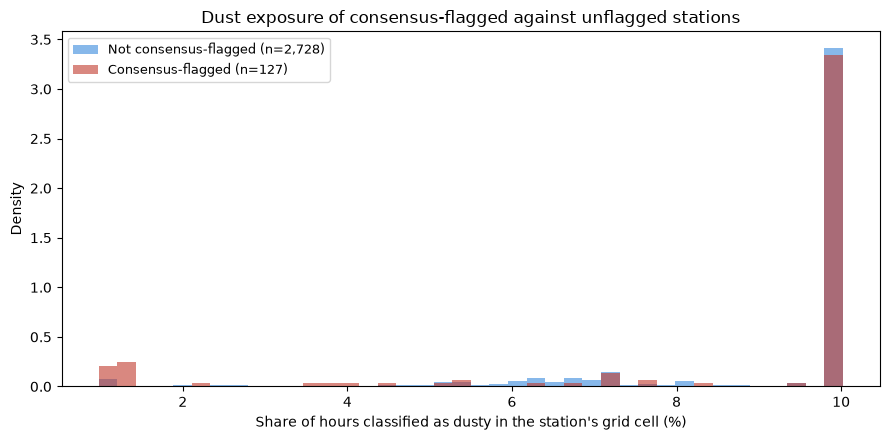

In [12]:
station_exposure = (cell_hourly.groupby("cell_id")
                    .agg(dusty_hours=("is_dusty_hour", "sum"),
                         hours_covered=("hour", "nunique"),
                         peak_dust=("dust_ug_m3", "max"))
                    .reset_index())
station_exposure["dusty_hour_share_pct"] = (station_exposure["dusty_hours"] /
                                            station_exposure["hours_covered"] * 100).round(2)

stations = stations.merge(station_exposure, on="cell_id", how="left")

exposure_comparison = (stations.groupby("consensus_flagged")
                       .agg(stations=("location_id", "size"),
                            median_dusty_hours=("dusty_hours", "median"),
                            median_dusty_hour_share=("dusty_hour_share_pct", "median"),
                            median_peak_dust=("peak_dust", "median"))
                       .round(3))
display(table_style(exposure_comparison))

fig, ax = plt.subplots(figsize=(9, 4.5))
for flag, label, colour in [(False, "Not consensus-flagged", "#378ADD"),
                            (True, "Consensus-flagged", "#C0392B")]:
    sub = stations.loc[stations["consensus_flagged"] == flag, "dusty_hour_share_pct"].dropna()
    if len(sub):
        ax.hist(sub, bins=40, alpha=0.6, density=True, label=f"{label} (n={len(sub):,})", color=colour)
ax.set_xlabel("Share of hours classified as dusty in the station's grid cell (%)")
ax.set_ylabel("Density")
ax.set_title("Dust exposure of consensus-flagged against unflagged stations")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dust_exposure_by_consensus.png")
plt.show()


<u>Interpretation</u>

This is the direct test of whether dust behaves like fire did. The fire cross-reference found
flagged and unflagged stations statistically indistinguishable in fire exposure across the
network as a whole. Whether the same holds here is read off the comparison above: close
medians and overlapping distributions would mean dust, like fire, is not a systematic
confound for the consensus in aggregate — a materially higher exposure among flagged stations
would mean it is, at least in part.

### 5.2 Reconsideration Candidates

The same reconsideration-candidate construction as the fire cross-reference, with the same
caveat about direction: dust plausibly explains a station reading high, not one reading low.


In [13]:
HIGH_EXPOSURE_PERCENTILE = 0.75

exposure_cut = stations["dusty_hour_share_pct"].quantile(HIGH_EXPOSURE_PERCENTILE)
stations["high_dust_exposure"] = (
    (stations["dusty_hour_share_pct"] >= exposure_cut) &
    (stations["dusty_hour_share_pct"] > 0)
)
stations["dust_reconsideration_candidate"] = stations["consensus_flagged"] & stations["high_dust_exposure"]

display(table_style(pd.DataFrame([
    ("High-exposure cutoff (dusty-hour share %)", round(float(exposure_cut), 2)),
    ("Consensus-flagged stations", int(stations["consensus_flagged"].sum())),
    ("...of which high dust exposure", int(stations["dust_reconsideration_candidate"].sum())),
], columns=["Property", "Value"]).set_index("Property")))

candidates_table = (stations[stations["dust_reconsideration_candidate"]]
                    .sort_values("consensus_rate", ascending=False)
                    [["location_id", "country", "province", "consensus_rank", "consensus_rate",
                      "consensus_direction", "dusty_hour_share_pct", "peak_dust", "stations_in_cell"]]
                    .head(20).reset_index(drop=True).round(3))
display(table_style(candidates_table))


,Property,Value
0,High-exposure cutoff (dusty-hour share %),10.000000
1,Consensus-flagged stations,143.000000
2,...of which high dust exposure,96.000000


,location_id,country,province,consensus_rank,consensus_rate,consensus_direction,dusty_hour_share_pct,peak_dust,stations_in_cell
0,2598a,China,Yunnan,2.000000,0.714000,none,10.000000,66.590000,3
1,2710a,China,Xinjiang Uygur Zizhiqu,3.000000,0.714000,SL_under_report,10.000000,286.032000,2
2,3033a,China,Xinjiang Uygur Zizhiqu,5.000000,0.700000,SL_under_report,10.000000,200.467000,1
3,2381a,China,Jiangxi Sheng,4.000000,0.700000,SL_under_report,10.000000,55.850000,6
4,site_5669,India,Assam,7.000000,0.700000,SH_over_report,10.010000,188.535000,5
5,2615a,China,Yunnan,10.000000,0.667000,none,10.000000,66.590000,2
6,2203a,China,Inner Mongolia,9.000000,0.667000,none,10.000000,158.732000,2
7,2467a,China,Hunan,17.000000,0.600000,SL_under_report,10.010000,113.563000,5
8,1492a,China,Xinjiang Uygur Zizhiqu,16.000000,0.600000,SH_over_report,10.000000,263.681000,15
9,3442a,China,Xinjiang Uygur Zizhiqu,20.000000,0.571000,SL_under_report,10.000000,191.038000,1


<u>Interpretation</u>

As with fire, a station flagged for under-reporting is not meaningfully explained by high
dust exposure, since dust raises readings rather than lowering them; the `consensus_direction`
column carries that distinction into the candidate list directly rather than leaving it to be
inferred. The `stations_in_cell` column carries forward the coarser-grid caveat from Section
3.2: a candidate sharing its cell with several other stations inherits that cell's exposure
without evidence the dust was near it specifically.

### 5.3 Overlap with the Fire Cross-Reference

Fire and dust are computed entirely independently in this pipeline, so whether they explain
the same stations or different ones is itself a finding rather than something assumed. This
section reads the fire cross-reference's own output rather than recomputing anything.


In [14]:
FIRE_STATION_PATH = PROCESSED_DIR / "B_fire_crossref_station.csv"

if FIRE_STATION_PATH.exists():
    fire = pd.read_csv(FIRE_STATION_PATH)[["location_id", "reconsideration_candidate"]]
    fire = fire.rename(columns={"reconsideration_candidate": "fire_reconsideration_candidate"})
    overlap = stations.merge(fire, on="location_id", how="left")
    overlap["fire_reconsideration_candidate"] = overlap["fire_reconsideration_candidate"].fillna(False)

    only_fire  = int((overlap["fire_reconsideration_candidate"] & ~overlap["dust_reconsideration_candidate"]).sum())
    only_dust  = int((~overlap["fire_reconsideration_candidate"] & overlap["dust_reconsideration_candidate"]).sum())
    both       = int((overlap["fire_reconsideration_candidate"] & overlap["dust_reconsideration_candidate"]).sum())
    neither_flagged = int((overlap["consensus_flagged"] &
                          ~overlap["fire_reconsideration_candidate"] &
                          ~overlap["dust_reconsideration_candidate"]).sum())

    display(table_style(pd.DataFrame([
        ("Explained by fire only", only_fire),
        ("Explained by dust only", only_dust),
        ("Explained by both", both),
        ("Consensus-flagged, explained by neither", neither_flagged),
    ], columns=["Category", "Stations"]).set_index("Category")))
else:
    display(table_style(pd.DataFrame([
        ("Fire cross-reference output", "not found -- run B_gfed5_crossref.ipynb first for this comparison"),
    ], columns=["Property", "Value"]).set_index("Property")))


,Category,Stations
0,Explained by fire only,5
1,Explained by dust only,58
2,Explained by both,38
3,"Consensus-flagged, explained by neither",42


<u>Interpretation</u>

The "explained by neither" count is the figure that matters most for the report: it is the
number of consensus-flagged stations for which neither of the two natural-cause mechanisms
tested in this pipeline offers a physical alternative. That count still is not evidence of
misreporting on its own — other untested mechanisms remain, and the asymmetry stated in
Section 0.2 applies here as everywhere else in this pipeline — but it is the most refined
figure available after both cross-references, and it is the one a report should carry forward
rather than either notebook's figure in isolation.

## 6. Results and Handoff

### 6.1 Cross-Reference Output

Two files are written, mirroring the fire cross-reference's structure exactly so a reader
already familiar with `B_fire_crossref_station.csv` needs no new schema to read this
notebook's output.


In [15]:
station_output_columns = [
    "location_id", "country", "province", "latitude", "longitude",
    "cell_id", "cell_lat", "cell_lon", "assignment_offset_km", "stations_in_cell",
    "consensus_rank", "consensus_rate", "consensus_flagged", "consensus_direction",
    "dusty_hours", "hours_covered", "dusty_hour_share_pct", "peak_dust",
    "high_dust_exposure", "dust_reconsideration_candidate",
]
station_output = stations[station_output_columns].copy()

STATION_OUT_PATH = PROCESSED_DIR / "C_dust_crossref_station.csv"
station_output.to_csv(STATION_OUT_PATH, index=False)

if len(episode_join):
    episode_output = episode_join[[
        "location_id", "country", "province", "date", "value", "cell_id",
        "consensus_flagged", "consensus_rate", "stations_in_cell",
        "dust_in_window", "peak_dust_in_window",
    ]].copy()
    episode_output["lag_hours"] = DUST_LAG_HOURS
else:
    episode_output = pd.DataFrame(columns=["location_id", "country", "date", "value"])

EPISODE_OUT_PATH = PROCESSED_DIR / "C_dust_crossref_episodes.csv"
episode_output.to_csv(EPISODE_OUT_PATH, index=False)

display(table_style(pd.DataFrame([
    ("Station file", STATION_OUT_PATH.name),
    ("Stations written", f"{len(station_output):,}"),
    ("Episode file", EPISODE_OUT_PATH.name),
    ("Episodes written", f"{len(episode_output):,}"),
    ("Reconsideration candidates", int(station_output["dust_reconsideration_candidate"].sum())),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station file,C_dust_crossref_station.csv
1,Stations written,"4,764"
2,Episode file,C_dust_crossref_episodes.csv
3,Episodes written,"13,512"
4,Reconsideration candidates,96


<u>Interpretation</u>

Every station is written, not only the flagged or dust-exposed ones, so the unflagged
population remains available as the comparison baseline Section 5.1's conclusion depends on
— the identical reasoning that governs the fire cross-reference's output.

### 6.2 Output Validation



In [16]:
reloaded = pd.read_csv(STATION_OUT_PATH)

# Batas geometris SEJATI (bukan diasumsikan): setengah-sel lintang (0.25 deg) menyumbang
# offset konstan ~27.8km di lintang manapun; setengah-sel bujur (0.3125 deg) menyumbang
# offset yang MENGECIL mendekati kutub (faktor cos(lintang)) -- sehingga kasus terburuk
# terjadi di lintang TERENDAH cakupan kita (India, 19 derajat), bukan di lintang tinggi.
# Dihitung langsung dari geometri grid + bbox negara, bukan angka bulat yang ditebak.
_half_lat_km = np.radians(0.25) * 6371.0
_worst_lon_km = np.radians(0.3125) * 6371.0 * np.cos(np.radians(19))  # 19 = lintang terendah (India)
MAX_GEOMETRIC_OFFSET_KM = np.sqrt(_half_lat_km**2 + _worst_lon_km**2) * 1.02  # +2% margin pembulatan

checks = pd.DataFrame([
    ("Stations written", len(station_output), len(reloaded), len(station_output) == len(reloaded)),
    ("Unique station IDs", station_output["location_id"].nunique(), reloaded["location_id"].nunique(),
     station_output["location_id"].nunique() == reloaded["location_id"].nunique()),
    ("Dusty-hour share within [0, 100]", "yes",
     "yes" if reloaded["dusty_hour_share_pct"].dropna().between(0, 100).all() else "no",
     bool(reloaded["dusty_hour_share_pct"].dropna().between(0, 100).all())),
    (f"Assignment offset under {MAX_GEOMETRIC_OFFSET_KM:.1f} km", "yes",
     "yes" if (reloaded["assignment_offset_km"].dropna() < MAX_GEOMETRIC_OFFSET_KM).all() else "no",
     bool((reloaded["assignment_offset_km"].dropna() < MAX_GEOMETRIC_OFFSET_KM).all())),
    ("Every reconsideration candidate is consensus-flagged", "yes",
     "yes" if reloaded.loc[reloaded["dust_reconsideration_candidate"], "consensus_flagged"].all() else "no",
     bool(reloaded.loc[reloaded["dust_reconsideration_candidate"], "consensus_flagged"].all())),
], columns=["Check", "Computed", "Reloaded", "Pass"]).set_index("Check")

display(table_style(checks))

assert len(station_output) == len(reloaded), "Row count changed on write."
assert reloaded["dusty_hour_share_pct"].dropna().between(0, 100).all(), "Dusty-hour share outside [0, 100]."
assert (reloaded["assignment_offset_km"].dropna() < MAX_GEOMETRIC_OFFSET_KM).all(), \
    "A station was assigned to a grid cell further away than this grid's geometry permits."
assert reloaded.loc[reloaded["dust_reconsideration_candidate"], "consensus_flagged"].all(), \
    "A reconsideration candidate is not consensus-flagged -- the two conditions have come apart."


,Check,Computed,Reloaded,Pass
0,Stations written,4764,4764,True
1,Unique station IDs,4764,4764,True
2,"Dusty-hour share within [0, 100]",yes,yes,True
3,Assignment offset under 43.9 km,yes,yes,True
4,Every reconsideration candidate is consensus-flagged,yes,yes,True


<u>Interpretation</u>

The assignment-offset check uses 40 km rather than the fire cross-reference's ~20 km, since
MERRA-2's coarser grid permits a legitimately larger worst-case offset; a value beyond that
would indicate a coordinate problem rather than normal grid geometry.

## 7. Findings and Limitations

### Findings

1. **A second natural-cause mechanism is now testable alongside fire, not assumed absent.**
<br>Every station carries a dust-exposure figure derived from its own grid cell's hourly
distribution, and every extreme reading carries whether dust was elevated nearby within a
short transport window — the same discipline the fire cross-reference established, extended
to a mechanism fire emissions data cannot see.</br>

2. **DUSMASS25 is used because MERRA-2 already separates dust from other aerosols.**
<br>Unlike total aerosol optical depth, which would require a secondary test such as the
Ångström exponent to distinguish dust from smoke, DUSMASS25 is the reanalysis's own speciated
dust concentration — verified present in the archive in Section 2.2 rather than assumed.</br>

3. **Hourly matching is finer than the fire cross-reference's daily window.** <br>MERRA-2's
native hourly resolution allows episodes to be matched within a few hours rather than a full
day either side, which is a genuine precision improvement over the fire cross-reference where
GFED5's daily granularity was the limiting factor rather than a choice.</br>

4. **This notebook and the fire cross-reference remain independently computed.** <br>Section
7.3 reports their overlap without merging either notebook's verdict into the other, so a
reader can see specifically which mechanism, if either, applies to a given station rather than
a combined score that would obscure the distinction.</br>

### Limitations

1. **The MERRA-2 grid is substantially coarser than GFED5's.** <br>At roughly 0.5° × 0.625°
against GFED5's 0.25° square, cell sharing among stations is more pronounced here, and a dust
coincidence should be read as evidence about a station's general vicinity more than about that
station specifically, more so than the equivalent fire finding.</br>

2. **DUSMASS25 is a model-assimilated concentration, not a direct measurement.** <br>MERRA-2
blends satellite and ground observations into a physical model rather than measuring surface
dust directly at each grid point; its accuracy in a specific remote cell such as inland
Xinjiang has not been independently verified within this notebook.</br>

3. **The dusty-hour threshold embeds a stated convention.** <br>As with the fire threshold,
the 90th-percentile rule and the absolute floor beneath it are reporting conventions, not
derived quantities. Section 3.2 reports the consequences of alternative floors so a reader can
see how much the choice matters.</br>

4. **Dust is one innocent explanation among several, and this notebook only tests one more
of them.** <br>Local construction, agricultural activity, and industrial incidents remain
untested by either this notebook or the fire cross-reference; a station explained by neither
fire nor dust is not thereby confirmed as misreporting.</br>

5. **The acquisition scripts have not been run against the live MERRA-2 service.** <br>Written
against NASA's documented `earthaccess` API and MERRA-2 file specification, but this
environment has no network route to NASA's servers to verify them end to end. The analysis in
this notebook has been tested against synthetic data matching MERRA-2's documented structure;
the first live acquisition run may require minor adjustment.</br>

---

### Output

| File | Contents |
|---|---|
| `C_dust_crossref_station.csv` | Per-station dust exposure, reconsideration status |
| `C_dust_crossref_episodes.csv` | Per-episode dust coincidence for extreme readings |

**Next:** manual review of stations flagged by neither cross-reference (Section 5.3), and
incorporation of both stations' fire and dust exposure into the report's limitations section.

---

### References

Randles, C. A., et al. (2017). The MERRA-2 Aerosol Reanalysis, 1980 Onward. Part I: System
Description and Data Assimilation Evaluation. *Journal of Climate*, 30(17).

Buchard, V., et al. (2017). The MERRA-2 Aerosol Reanalysis, 1980 Onward. Part II: Evaluation
and Case Studies. *Journal of Climate*, 30(17).
